In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense

In [ ]:
data = pd.read_csv("/content/merged.csv")
data.head(5)

,time_seconds,flow_node2,flow_node3,flow_node4,flow_node5,flow_node6,flow_node7,flow_node8,flow_node9,pressure_node2,...,leak_node12,leak_node13,leak_node14,leak_x,leak_y,leak_z,weekday_flag,leak_status,is_leak,day_id
0,0,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,0,0,0,0,0,0,1,0,0,labelled_data_1
1,600,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,0,0,0,0,0,0,1,0,0,labelled_data_1
2,1200,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,0,0,0,0,0,0,1,0,0,labelled_data_1
3,1800,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,0,0,0,0,0,0,1,0,0,labelled_data_1
4,2400,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,0,0,0,0,0,0,1,0,0,labelled_data_1


In [ ]:
drop_cols = [col for col in data.columns if col.startswith(("x_", "y_", "z_", "leak_"))]
drop_cols += ["day_id", "is_leak"]
X = data.drop(columns=drop_cols + ["leak_status"])
Y = data["leak_status"]

In [ ]:
X.head(5)

,time_seconds,flow_node2,flow_node3,flow_node4,flow_node5,flow_node6,flow_node7,flow_node8,flow_node9,pressure_node2,...,pressure_node9,volume_node2,volume_node3,volume_node4,volume_node5,volume_node6,volume_node7,volume_node8,volume_node9,weekday_flag
0,0,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,54.87,18.5,3.0,10.0,1.5,4.0,18.5,5.5,13.0,1
1,600,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,54.87,18.5,3.0,10.0,1.5,4.0,18.5,5.5,13.0,1
2,1200,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,54.87,18.5,3.0,10.0,1.5,4.0,18.5,5.5,13.0,1
3,1800,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,54.87,18.5,3.0,10.0,1.5,4.0,18.5,5.5,13.0,1
4,2400,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,54.87,18.5,3.0,10.0,1.5,4.0,18.5,5.5,13.0,1


In [ ]:
Y.head(5)

,leak_status
0,0
1,0
2,0
3,0
4,0


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(Y)
y_encoded

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:

X_train, X_test, Y_train, Y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
data["leak_status"].value_counts()

,count
leak_status,
0,1450
10,1450
11,1450
12,1450
13,1450
14,1450


In [ ]:
classes = np.unique(y_encoded)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_encoded
)

class_weights = dict(zip(classes, class_weights))
class_weights

{np.int64(0): np.float64(1.0),
 np.int64(1): np.float64(1.0),
 np.int64(2): np.float64(1.0),
 np.int64(3): np.float64(1.0),
 np.int64(4): np.float64(1.0),
 np.int64(5): np.float64(1.0)}

In [ ]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    Dense(64, activation="relu"),
    layers.Dropout(0.3),
    Dense(len(classes), activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,102 (47.27 KB)

 Trainable params: 12,102 (47.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
history = model.fit(
    X_train, Y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2919 - loss: 1.6726 - val_accuracy: 0.5517 - val_loss: 1.0664
Epoch 2/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5378 - loss: 1.0663 - val_accuracy: 0.5474 - val_loss: 0.9224
Epoch 3/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5673 - loss: 0.9148 - val_accuracy: 0.5632 - val_loss: 0.8796
Epoch 4/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5770 - loss: 0.8755 - val_accuracy: 0.5805 - val_loss: 0.8650
Epoch 5/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6032 - loss: 0.8489 - val_accuracy: 0.5647 - val_loss: 0.8615
Epoch 6/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6107 - loss: 0.8310 - val_accuracy: 0.5826 - val_loss: 0.8468
Epoch 7/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5985 - loss: 0.8297 - val_accuracy: 0.5891 - val_loss: 0.8379
Epoch 8/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6193 - loss: 0.8219 - val_accuracy: 0.

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(Y_test, y_pred, target_names=label_encoder.classes_.astype(str)))

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       290
          10       0.93      0.83      0.88       290
          11       0.79      0.73      0.76       290
          12       0.68      0.79      0.73       290
          13       0.76      0.67      0.71       290
          14       0.71      0.73      0.72       290

    accuracy                           0.77      1740
   macro avg       0.78      0.77      0.78      1740
weighted avg       0.78      0.77      0.78      1740



In [ ]:
print(y_pred)

[4 2 4 ... 5 1 4]


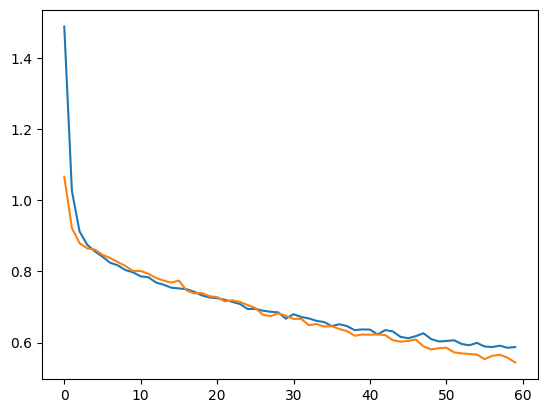

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

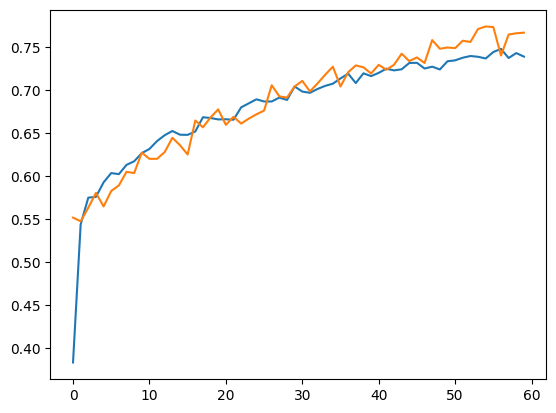

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

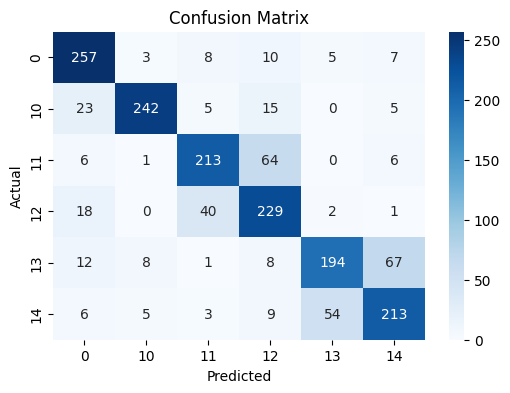

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

mat = confusion_matrix(Y_test, y_pred, labels=np.unique(y_encoded))

plt.figure(figsize=(6, 4))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
def compute_dvdt(data, volume_cols, time_col="time_seconds"):

  dt = data[time_col].diff().fillna(0).replace(0, 1)

  for col in volume_cols:
    node = col.split("_")[-1]
    data[f"dVdt_{node}"] = data[col].diff().fillna(0) / dt

  return data

In [ ]:
import numpy as np

def compute_beta_dict(df, leak_status_col="leak_status",
                      pressure_cols=None, net_flow_cols=None, dVdt_cols=None):

    beta_dict = {}
    for node in range(10, 15):
        leak_day_df = df[df[leak_status_col] == node]
        if len(leak_day_df) == 0:
            continue

        obs_leak = leak_day_df[net_flow_cols].values - leak_day_df[dVdt_cols].values
        obs_leak = obs_leak.mean(axis=1)


        pressure = leak_day_df[pressure_cols[0]].values
        sqrt_p = np.sqrt(np.clip(pressure, 1e-6, None))

        beta = np.sum(obs_leak * sqrt_p) / np.sum(sqrt_p ** 2)
        beta_dict[node] = float(beta)

    return beta_dict


In [ ]:
import tensorflow as tf

def prepare_physics_tensors(X_df):

    X_tensor = tf.convert_to_tensor(X_df.values, dtype=tf.float32)
    col_index = {col: idx for idx, col in enumerate(X_df.columns)}

    pressure_nodes = {i: X_tensor[:, col_index[f"pressure_node{i}"]] for i in range(2, 10)}
    net_flow_nodes = [X_tensor[:, col_index[f"flow_node{i}"]] for i in range(2, 10)]
    dVdt_nodes = [X_tensor[:, col_index[f"dVdt_node{i}"]] for i in range(2, 10)]

    return pressure_nodes, net_flow_nodes, dVdt_nodes


In [ ]:
def physics_informed_loss(beta_dict, col_index,
                          lambda_c=0.01, lambda_l=0.01):

    def loss(y_true, y_pred_and_X):
        y_pred, X_batch = y_pred_and_X

        ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

        pressures = [X_batch[:, col_index[f"pressure_node{i}"]] for i in range(2, 10)]
        net_flows = [X_batch[:, col_index[f"flow_node{i}"]] for i in range(2, 10)]
        dVdts    = [X_batch[:, col_index[f"dVdt_node{i}"]] for i in range(2, 10)]

        avg_pressure = tf.reduce_mean(tf.stack(pressures, axis=1), axis=1)

        leak_flow_model = 0.0
        for idx, node_id in enumerate(range(10, 15), start=1):
            beta = beta_dict.get(node_id, 1.0)
            leak_flow_model += y_pred[:, idx] * beta * tf.sqrt(tf.maximum(avg_pressure, 1e-6))

        obs_leak = tf.reduce_mean([nf - dv for nf, dv in zip(net_flows, dVdts)], axis=0)

        leak_residual = obs_leak - leak_flow_model
        leak_loss = tf.reduce_mean(tf.square(leak_residual))

        cont_residuals = [nf - dv - leak_flow_model for nf, dv in zip(net_flows, dVdts)]
        cont_residual = tf.reduce_mean(cont_residuals, axis=0)
        cont_loss = tf.reduce_mean(tf.square(cont_residual))

        return ce_loss + lambda_l * leak_loss + lambda_c * cont_loss

    return loss



In [ ]:

volume_cols = [f"volume_node{i}" for i in range(2, 10)]
data = compute_dvdt(data, volume_cols)




In [ ]:
data.head(5)

,time_seconds,flow_node2,flow_node3,flow_node4,flow_node5,flow_node6,flow_node7,flow_node8,flow_node9,pressure_node2,...,is_leak,day_id,dVdt_node2,dVdt_node3,dVdt_node4,dVdt_node5,dVdt_node6,dVdt_node7,dVdt_node8,dVdt_node9
0,0,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,0,labelled_data_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,600,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,0,labelled_data_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1200,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,0,labelled_data_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1800,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,0,labelled_data_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2400,1.85,0.3,1.0,0.15,0.4,1.85,0.55,1.3,54.87,...,0,labelled_data_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
pressure_cols = [f"pressure_node{i}" for i in range(2, 10)]
net_flow_cols = [f"flow_node{i}" for i in range(2, 10)]
dVdt_cols = [f"dVdt_node{i}" for i in range(2, 10)]
beta_dict = compute_beta_dict(data, "leak_status", pressure_cols, net_flow_cols, dVdt_cols)
print("Beta dict:", beta_dict)

data.drop(columns=["day_id"], inplace=True)

pressure_nodes, net_flow_nodes, dVdt_nodes = prepare_physics_tensors(data)

Beta dict: {10: 0.5565216671938664, 11: 0.7256110572116811, 12: 0.677138944134961, 13: 0.6780810315693842, 14: 0.6772160165911087}


In [ ]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(X_train.shape[1],))

x = layers.Dense(128, activation="relu")(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs_class = layers.Dense(6, activation="softmax", name="class_output")(x)

outputs_features = layers.Lambda(lambda z: z, name="feature_output")(inputs)

model_pinn = models.Model(inputs=inputs, outputs=[outputs_class, outputs_features])

In [ ]:
col_index = {col: idx for idx, col in enumerate(X.columns)}

model_pinn.compile(
    optimizer="adam",
    loss={"class_output": physics_informed_loss(beta_dict, col_index)},
    metrics={"class_output": "accuracy"}
)

In [ ]:
history_2 = model.fit(
    X_train, Y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7335 - loss: 0.5918 - val_accuracy: 0.7730 - val_loss: 0.5489
Epoch 2/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7493 - loss: 0.5679 - val_accuracy: 0.7651 - val_loss: 0.5564
Epoch 3/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7429 - loss: 0.5880 - val_accuracy: 0.7672 - val_loss: 0.5393
Epoch 4/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7662 - loss: 0.5437 - val_accuracy: 0.7838 - val_loss: 0.5315
Epoch 5/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7552 - loss: 0.5674 - val_accuracy: 0.7845 - val_loss: 0.5328
Epoch 6/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7556 - loss: 0.5642 - val_accuracy: 0.7924 - val_loss: 0.5284
Epoch 7/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7530 - loss: 0.5712 - val_accuracy: 0.7909 - val_loss: 0.5341
Epoch 8/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7629 - loss: 0.5631 - val_accuracy: 0.

In [ ]:
y_pred_pinn = np.argmax(model.predict(X_test), axis=1)
print(classification_report(Y_test, y_pred_pinn, target_names=label_encoder.classes_.astype(str)))

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       290
          10       0.97      0.83      0.90       290
          11       0.83      0.81      0.82       290
          12       0.75      0.86      0.80       290
          13       0.78      0.74      0.76       290
          14       0.79      0.80      0.80       290

    accuracy                           0.83      1740
   macro avg       0.83      0.83      0.83      1740
weighted avg       0.83      0.83      0.83      1740



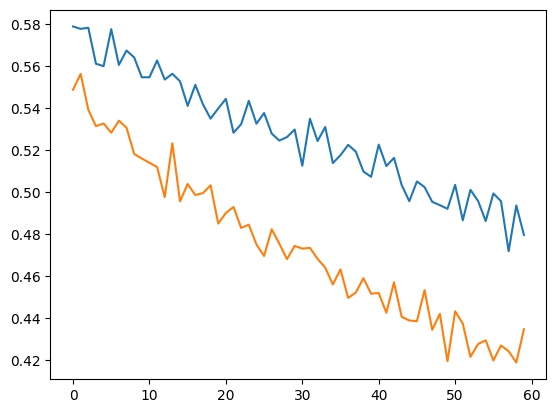

In [ ]:
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])

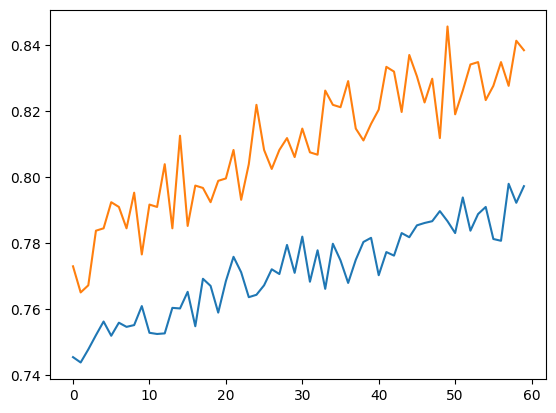

In [ ]:
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])

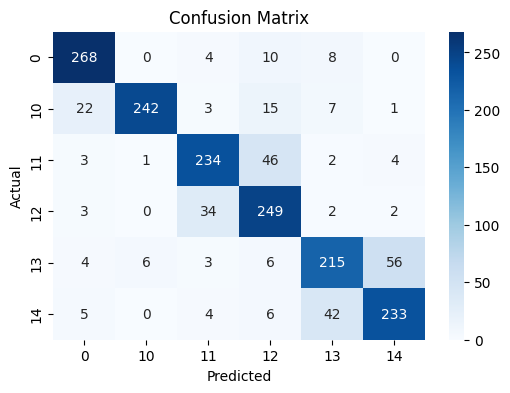

In [ ]:
mat_pinn = confusion_matrix(Y_test, y_pred_pinn, labels=np.unique(y_encoded))

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(mat_pinn, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()